In [ ]:
import pickle
import numpy as np 
import re 
from pathlib import Path
import pandas as pd

%matplotlib inline 

import matplotlib.pyplot as plt 
import seaborn as sns
# from matplotlib.ticker import FormatStrFormatter



# Compare Model confidence judgements to accuracy 



In [2]:
# plot_out_dir = Path('/om2/user/imgriff/projects/Auditory-Attention/ARO_2023_figs/')

## Human v Model plots

### Get TIMIT pandas for metadata

In [3]:
df_paths = list(Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes_mturk/').glob('*dataset*.pdpkl'))
# df_path = df_paths[:] # want sets 1 & 2 for now|

In [4]:
# df_paths

In [5]:
meta_df = []
for path in df_paths:
    df = pd.read_pickle(path)
    df['stim_subset'] = int(re.search('dataset_(-?\d+)', path.stem).group(0).split('_')[-1])
    meta_df.append(df)
meta_df = pd.concat(meta_df, axis=0)

: 

: 

In [ ]:
# pd.concat(meta_df, axis=0)

### Get experimental results csv

In [ ]:
results_path = Path('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/')
# results_df = pd.read_csv(results_path / 'Batch_367265_batch_results.csv')

# results_files = [file for file in results_path.glob("*.csv") if file.stem != "Batch_367574_batch_results" ]

results_files = list(results_path.glob("*.csv"))

In [ ]:
results_files

[PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4926170_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4928442_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934342_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4934809_batch_results.csv'),
 PosixPath('/om2/user/imgriff/projects/cocktail_party/datasets/timit_attention_task/mturk_attn_v01/Batch_4941864_batch_results.csv')]

In [ ]:
## Get condition map to translate stimuli file names to relevant condition variables
word_and_speaker_encodings = pickle.load( open( "/om2/user/imgriff/projects/Auditory-Attention/word_and_speaker_encodings_jsinv3.pckl", "rb" )) 
class_map = word_and_speaker_encodings['word_idx_to_word']

# file_name = truth['stim_file_name'][100]

def file_name_to_labels(file_name):
    file = Path(file_name)
    word = re.search('word_(-?\d+)', file.stem).group(0).split('_')[-1]
    word = class_map[int(word)]
    orig_df_ix = re.search('stim_(-?\d+)', file.stem).group(0).split('_')[-1]
    orig_dataset_ix = re.search('set_(-?\d+)', file.stem).group(0).split('_')[-1]
    if 'ssn' in file.stem:
        cond = 'ssn'
        speaker_sex = 'ssn'
    elif "catch_trial" not in file.as_posix():
        cond = re.search('cond_(-?\d+)', file.stem).group(0).split('_')[-1]
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    if "catch_trial" in file.as_posix():
        snr = 'clean'
        cond = 'catch_trial'
        speaker_sex = re.search('speaker_(\w)', file.stem).group(0).split('_')[-1]
    else:
        snr = re.search('snr_(-?\d+)', file.stem).group(0).split('_')[-1]
    return int(orig_dataset_ix), word, snr, cond, speaker_sex, int(orig_df_ix)


In [ ]:
# Get data from each batch file 
dfs = []
for ix, file in enumerate(results_files):
    df = pd.read_csv(file)
    df = df.rename(index={ix:f'p{ix}' for ix in range(len(df))})

    truth = df[[col for col in list(df) if 'Audio_Exp' in col]]
    truth = truth.T
    truth = truth.rename(index={ix:f"trial {ix.split('_')[-1]}" for ix in truth.index})
    truth = truth.dropna(axis='columns')
    truth = pd.melt(truth.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'stim_path',
                    ignore_index=False)

    responses = df[[col for col in list(df) if 'Resp_Exp' in col]]
    responses = responses.T
    responses = responses.rename(columns={0:"guessed_word"}, index={ix:f"trial {ix.split('_')[-1]}" for ix in responses.index})
    responses = responses.dropna(axis='columns')

    responses = pd.melt(responses.reset_index(), 
                    id_vars=['index'], 
                    var_name = 'participant',
                    value_name = 'guessed_word',
                    ignore_index=False)

    results = responses.merge(truth, on=['index', 'participant'])
    results['participant'] = results['participant'] + f'_{ix}' 

    results['stim_subset'], results['true_word'], results['snr'], results['distractor_condition'], results['target_sex'], results['orig_df_ix'] = zip(*results['stim_path'].map(file_name_to_labels))

    ## Get distractor information from dfs 
    for stim_subset in results.stim_subset.unique():
        # get ixs for samples with this dataset
        result_ixs = np.where(results.stim_subset == stim_subset)[0]
        # get matching metadata
        meta_subset = meta_df[meta_df.stim_subset == stim_subset]
        results.loc[result_ixs, 'distractor_words'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_words']].values
        results.loc[result_ixs, 'distractor_sex'] = meta_subset.loc[results.loc[result_ixs, 'orig_df_ix'], ['distractor_sex']].values
    dfs.append(results)
results = pd.concat(dfs)
print(results.shape)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

(9100, 12)


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr_value = np.asarray(value)
/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/pandas/core/internals/blocks.py:938: VisibleDeprecationWarning: Creating an ndarray from r

#### Process results csv to plotting format

In [12]:
len(results.participant.unique())

50

In [13]:
results['accuracy'] = (results['guessed_word'] == results['true_word']).astype('int')

In [14]:
get_confusion = lambda row: int(row.guessed_word in row.distractor_words)

results['confusions'] = results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [15]:
catch_trial_particiapnt_performance = results[results.distractor_condition == 'catch_trial'].groupby('participant').accuracy.mean()


In [16]:
len(catch_trial_particiapnt_performance) # catch trial performance for each participant 

50

In [17]:
# filter out bad performers on catch trials  
good_participants = catch_trial_particiapnt_performance[catch_trial_particiapnt_performance > 9/12].index

In [18]:
good_results = results[results.participant.isin(good_participants)]

## Get model results all subsets

In [19]:
parent_path = Path('/om2/user/rphess/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_BinauralCueWReportW/')
timit_results = list(parent_path.rglob("*.csv"))

In [20]:
timit_results

[PosixPath('/om2/user/rphess/Auditory-Attention/attn_cue_models/attn_timit_task/TIMIT_attn_task__all_targets_BinauralCueWReportW/version_2/metrics.csv')]

In [22]:
model_results = pd.read_csv(timit_results[0])

In [23]:
model_results.shape

(41492, 4)

In [24]:
model_results.head()

,ACC/test_fg_acc,pred_word_ix,model_confidence,step
0,0.0,532.0,0.217647,0
1,0.0,161.0,0.090074,1
2,0.0,192.0,0.061434,2
3,0.0,645.0,0.024780,3
4,0.0,387.0,0.022917,4


In [25]:
model_results = model_results.rename(columns={'ACC/test_fg_acc':"accuracy",
                             'step':'orig_df_ix'}, 
                      index={ix:f"trial {ix}" for ix in model_results.index})
model_results['pred_word_ix'] = model_results['pred_word_ix'].astype('int') 

In [26]:
### import parent model stim df
out_path = Path('/om2/user/imgriff/datasets/timit/attn_task_dataframes/')

model_meta_df = pd.read_pickle(out_path / 'timit_attn_stim_for_model_all_targets_metadata_only.pdpkl')

In [27]:
model_meta_df = model_meta_df.loc[:,~model_meta_df.columns.str.contains('signal')]

In [28]:
import pickle 
model_word_to_ix = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
model_class_map = {v:k for k,v in model_word_to_ix.items()}

In [29]:
model_results['guessed_word'] = model_results['pred_word_ix'].map(model_class_map)

### Get metadata from timit df 
model_results['true_word'] = model_meta_df.loc[model_results.orig_df_ix, ['word']].values
model_results['distractor_words'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_words']].values
model_results['distractor_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_sex']].values
model_results['snr'] = model_meta_df.loc[model_results.orig_df_ix, ['snrs']].values.astype('str')
model_results['distractor_condition'] = model_meta_df.loc[model_results.orig_df_ix, ['distractor_conditions']].values.astype('str')
model_results['target_sex'] = model_meta_df.loc[model_results.orig_df_ix, ['speaker_sex']].values


In [30]:
model_results

,accuracy,pred_word_ix,model_confidence,orig_df_ix,guessed_word,true_word,distractor_words,distractor_sex,snr,distractor_condition,target_sex
trial 0,0.0,532,0.217647,0,problems,programs,[working],m,-6,1,f
trial 1,0.0,161,0.090074,1,couple,novel,[medical],m,-6,1,f
trial 2,0.0,192,0.061434,2,district,should,[larger],m,-6,1,f
trial 3,0.0,645,0.024780,3,special,social,[caused],m,-6,1,f
trial 4,0.0,387,0.022917,4,longer,light,[young],m,-6,1,f
...,...,...,...,...,...,...,...,...,...,...,...
trial 41487,1.0,54,0.709375,41487,based,based,[based],f,-9,1,m
trial 41488,0.0,21,0.009461,41488,allowed,either,[taking],f,-9,1,m
trial 41489,0.0,479,0.006632,41489,other,through,[programs],f,-9,1,m
trial 41490,0.0,249,0.071053,41490,final,avoid,[friends],f,-9,1,m


In [31]:
model_results['confusions'] = model_results[['guessed_word', 'distractor_words']].apply(get_confusion, axis=1)

In [32]:
model_results['subject'] = 'model'
good_results['subject'] = 'human'

/tmp/ipykernel_44922/3491488986.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  good_results['subject'] = 'human'


In [33]:
all_results = pd.concat([good_results, model_results])

<a id='Attentive_listening_task'></a>
# Attentive listening task plots

In [34]:
# set ssn to noise for plots 
all_results = all_results.replace('ssn', 'noise', regex=True)

In [35]:
turk_results = all_results[all_results['subject'] == 'human']

turk_summary_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())



turk_conf_df = (turk_results.groupby(["snr", 'participant', "distractor_condition"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())




In [36]:
turk_summary_df.head()

,snr,participant,distractor_condition,mean
0,-3,p12_1,1,0.8
1,-3,p12_1,2,0.3
2,-3,p12_1,4,0.3
3,-3,p12_1,noise,0.4
4,-3,p18_1,1,0.5


## Summary  

In [37]:
## Process for confusions and sex comparisons

## map male/female to same/different 


def remap_sex_strs(target_sex, distractors):
    if isinstance(distractors,float):
        return distractors
    if distractors == 'noise':
        return distractors 
    same_diff = ''.join(['s' if char == target_sex else 'd' for char in distractors])
    return same_diff

all_results['distractor_type'] = all_results[['target_sex',
                                              'distractor_sex']].apply(lambda x: remap_sex_strs(x.target_sex, x.distractor_sex),
                                                    axis=1)


In [38]:
## Make distractor hue colors 

# distractor_hue_order = [cond for cond in results.distractor_sex.unique().astype('str')
#                         if 'm' in cond or 'f' in cond]

# distractor_hue_order = sorted(distractor_hue_order, key=lambda x: len(x))

from itertools import groupby


distractor_hue_order = ['s', 'd', 'ss', 'sd', 'dd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']

grouped_distractors = [list(set(items)) for length, items in groupby(distractor_hue_order, key=len)]
grouped_distractors = [sorted(elems) for elems in grouped_distractors]

distractor_palette = {}
print(grouped_distractors)

color_palettes = [sns.diverging_palette(220, 20, center="dark", n=2, as_cmap=False),
                sns.diverging_palette(145, 300, center="dark", s=60, n=3, as_cmap=False),
                sns.color_palette("coolwarm", n_colors=5, as_cmap=False)]


for g_ix, group in enumerate(grouped_distractors):
    n_in_group = len(group)
    for d_ix, dist in enumerate(group):
        distractor_palette[dist] = color_palettes[g_ix][d_ix]


distractor_palette['ssdd'] = distractor_palette['sd']

# skip 2 distractor condition
sex_distractor_palette = {k:v for k,v in distractor_palette.items() if len(k) !=2}
sex_distractor_hue_order = ['s', 'd', 'ssss', 'sssd', 'ssdd', 'sddd', 'dddd']


[['d', 's'], ['dd', 'sd', 'ss'], ['dddd', 'sddd', 'ssdd', 'sssd', 'ssss']]


In [39]:
## Get stats for sex similarity plots:

turk_results = all_results[all_results['subject'] == 'human']

turk_by_sex_accuracy_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .accuracy
                     .agg(["mean"])
                     .reset_index())

turk_by_sex_accuracy_df.rename(columns={'mean':'accuracy'}, inplace=True)
turk_by_sex_confusion_df = (turk_results.groupby(["snr", 'participant',
                                         "distractor_condition", "distractor_type"])
                     .confusions
                     .agg(["mean"])
                     .reset_index())
turk_by_sex_confusion_df.rename(columns={'mean':'confusions'}, inplace=True)




# turk_summary_df = (turk_results.groupby(["snr", 'participant',
#                                          "distractor_condition", "distractor_sex", 'target_sex'])
#                      .accuracy
#                      .agg(["mean"])
#                      .reset_index())

turk_by_sex_accuracy_df.head()

,snr,participant,distractor_condition,distractor_type,accuracy
0,-3,p12_1,1,d,1.0
1,-3,p12_1,1,s,0.6
2,-3,p12_1,2,dd,0.0
3,-3,p12_1,2,ds,0.0
4,-3,p12_1,2,sd,1.0


In [40]:
sex_acc = pd.merge(turk_by_sex_accuracy_df, all_results[all_results.subject=='model'], 
        on=['snr', 'participant', 'distractor_condition', 'distractor_type',
       'accuracy'],

        how='outer')
sex_acc['subject'][~sex_acc.participant.isna()] = 'human'

/tmp/ipykernel_44922/2228803891.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sex_acc['subject'][~sex_acc.participant.isna()] = 'human'


In [41]:
sex_name_update = {'s': "Same sex", 'd':'Different sex'}
sex_acc['distractor_type'] = sex_acc['distractor_type'].replace(sex_name_update)
turk_by_sex_confusion_df['distractor_type'] = turk_by_sex_confusion_df['distractor_type'].replace(sex_name_update)
sex_distractor_palette = {(sex_name_update[k] if k in sex_name_update.keys() else k):v 
                          for k,v in sex_distractor_palette.items()}

In [42]:
dist_name_update = {'1': "1 talker", '4':'4 talker', 'noise':'noise'}
turk_summary_df['distractor_condition'] = turk_summary_df['distractor_condition'].replace(dist_name_update)
all_results['distractor_condition'] = all_results['distractor_condition'].replace(dist_name_update)

sex_acc['distractor_condition'] = sex_acc['distractor_condition'].replace(dist_name_update)
turk_by_sex_confusion_df['distractor_condition'] = turk_by_sex_confusion_df['distractor_condition'].replace(dist_name_update)


In [43]:
sex_acc[sex_acc['subject'] == 'human']

,snr,participant,distractor_condition,distractor_type,accuracy,index,guessed_word,stim_path,stim_subset,true_word,target_sex,orig_df_ix,distractor_words,distractor_sex,confusions,subject,pred_word_ix,model_confidence
0,-3,p12_1,1 talker,Different sex,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
1,-3,p12_1,1 talker,Same sex,0.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
2,-3,p12_1,2,dd,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
3,-3,p12_1,2,ds,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
4,-3,p12_1,2,sd,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1232,3,p9_0,4 talker,dddd,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
1233,3,p9_0,4 talker,ddss,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
1234,3,p9_0,4 talker,ssdd,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN
1235,3,p9_0,4 talker,ssss,0.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,human,NaN,NaN


In [44]:
all_results

,index,participant,guessed_word,stim_path,stim_subset,true_word,snr,distractor_condition,target_sex,orig_df_ix,distractor_words,distractor_sex,accuracy,confusions,subject,pred_word_ix,model_confidence,distractor_type
546,trial 0,p5_0,below,https://mcdermottlab.mit.edu/mturk_stimuli/img...,11.0,appointed,-6,noise,noise,58,noise,noise,0.0,0,human,NaN,NaN,noise
547,trial 1,p5_0,coming,https://mcdermottlab.mit.edu/mturk_stimuli/img...,11.0,towards,-6,noise,noise,165,noise,noise,0.0,0,human,NaN,NaN,noise
548,trial 10,p5_0,country,https://mcdermottlab.mit.edu/mturk_stimuli/img...,11.0,country,3,4 talker,f,25,"[exchange, capital, being, around]",mfff,1.0,0,human,NaN,NaN,dsss
549,trial 100,p5_0,almost,https://mcdermottlab.mit.edu/mturk_stimuli/img...,11.0,lower,-6,1 talker,f,64,[almost],f,0.0,1,human,NaN,NaN,s
550,trial 101,p5_0,white,https://mcdermottlab.mit.edu/mturk_stimuli/img...,11.0,included,-3,1 talker,f,61,[white],f,0.0,1,human,NaN,NaN,s
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
trial 41487,NaN,NaN,based,NaN,NaN,based,-9,1 talker,m,41487,[based],f,1.0,1,model,54.0,0.709375,d
trial 41488,NaN,NaN,allowed,NaN,NaN,either,-9,1 talker,m,41488,[taking],f,0.0,0,model,21.0,0.009461,d
trial 41489,NaN,NaN,other,NaN,NaN,through,-9,1 talker,m,41489,[programs],f,0.0,0,model,479.0,0.006632,d
trial 41490,NaN,NaN,final,NaN,NaN,avoid,-9,1 talker,m,41490,[friends],f,0.0,0,model,249.0,0.071053,d


In [45]:
# fig, axs = plt.subplots(1,2, figsize=(14,6), sharey=False, sharex=False)

# g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
#             hue ='distractor_condition', linestyles='--', markers='.',
#             hue_order=hue_order, palette=distractor_palette,
#              errorbar=('ci', 95), n_boot=1000, seed=1,
#               ax=axs[0])

# g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'model_confidence', order=snr_order,
#             hue ='distractor_condition', linestyles='--', markers='.',
#             hue_order=hue_order, palette=distractor_palette,
#              errorbar=('ci', 95), n_boot=1000, seed=1,
#               ax=axs[1])

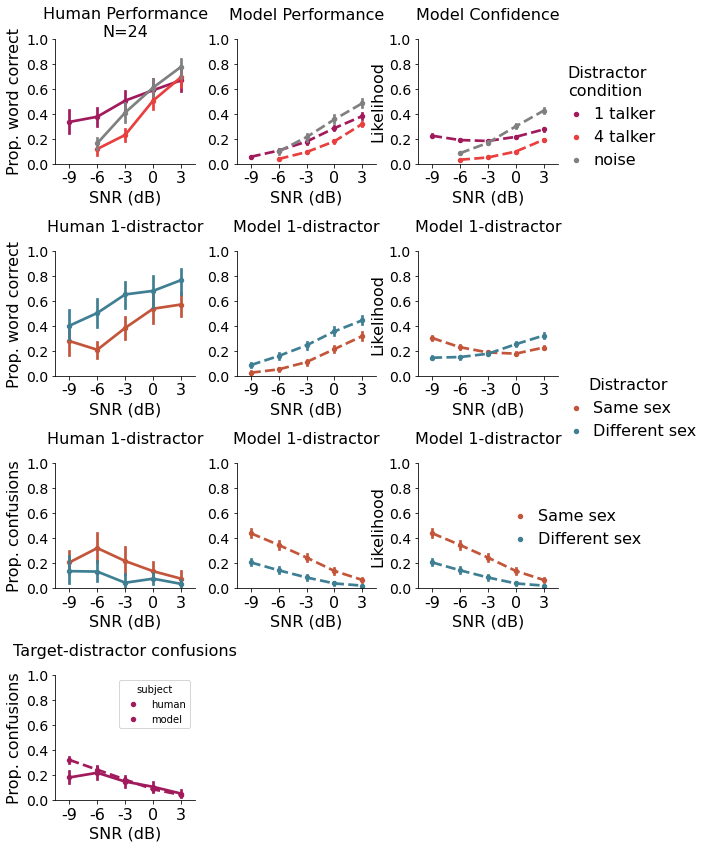

In [46]:
snr_order = ['-9', '-6', '-3', '0', '3' ]
hue_order = ['1 talker', '4 talker', 'noise']
sex_distractor_hue_order = ['Same sex', 'Different sex']
# y_labels = np.linspace(0.1,1,6).round(2)
fontsize = 16

distractor_cmap = sns.color_palette("rocket", 4, as_cmap=False)
distractor_palette = {cond:distractor_cmap[ix+1] for ix, cond in enumerate(hue_order[:3])}
distractor_palette['noise'] = 'grey'

n_participants = len(turk_summary_df.participant.unique())


fig, axs = plt.subplots(4,3, figsize=(9,14), sharey=False, sharex=False)
axs = axs.ravel()

# attn 
g = sns.pointplot( data=turk_summary_df, x = 'snr', y = 'mean', order=snr_order,
            hue ='distractor_condition',  error='sem', markers='.',
            hue_order=hue_order, palette=distractor_palette, 
            ax=axs[0])

g1 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_condition', linestyles='--', markers='.',
            hue_order=hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[1])

g2 = sns.pointplot( data=all_results[all_results.subject=='model'], x = 'snr', y = 'model_confidence', order=snr_order,
            hue ='distractor_condition', linestyles='--', markers='.',
            hue_order=hue_order, palette=distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[2])

# same diff sex acc
# 1 distractor 
g3 = sns.pointplot( data=sex_acc[(sex_acc.subject=='human') & (sex_acc.distractor_condition=='1 talker')],
              x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type',  error='sem', markers='.',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette, 
            ax=axs[3])

g4 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1 talker')], 
                   x = 'snr', y = 'accuracy', order=snr_order,
            hue ='distractor_type', linestyles='--',markers='.',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[4])
g5 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1 talker')], 
                   x = 'snr', y = 'model_confidence', order=snr_order,
            hue ='distractor_type', linestyles='--',markers='.',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[5])


# same diff sex confs 
g6 = sns.pointplot( data=turk_by_sex_confusion_df[turk_by_sex_confusion_df['distractor_condition']=='1 talker'],
              x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type',  error='sem', markers='.',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette, 
            ax=axs[6])

g7 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1 talker')], 
                   x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type', linestyles='--',markers='.',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[7])
g8 = sns.pointplot( data=sex_acc[(sex_acc.subject=='model') & (sex_acc.distractor_condition=='1 talker')], 
                   x = 'snr', y = 'confusions', order=snr_order,
            hue ='distractor_type', linestyles='--',markers='.',
            hue_order=sex_distractor_hue_order, palette=sex_distractor_palette,
             errorbar=('ci', 95), n_boot=1000, seed=1,
               ax=axs[8])


g9 = sns.pointplot( data=all_results[all_results.distractor_condition == '1 talker'],
                  x = 'snr', y = 'confusions', order=snr_order,
            hue ='subject', height=4, linestyles=['-', '--'],  markers=['.','.'],
            palette=[distractor_palette['1 talker']] * 2,
            ax=axs[9])





# attn word rec
axs[0].set_title(f"Human Performance\nN={n_participants}",fontsize=fontsize, pad = -20)
axs[1].set_title("Model Performance", fontsize=fontsize, pad = 20)
axs[2].set_title("Model Confidence", fontsize=fontsize, pad = 20)

axs[0].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')
axs[1].set_ylabel("", fontsize=fontsize)
axs[2].set_ylabel("Likelihood", fontsize=fontsize)

# same/diff sex word rec

axs[3].set_title("Human 1-distractor", fontsize=fontsize, pad = 20)
axs[4].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)
axs[5].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)

axs[3].set_ylabel("Prop. word correct", fontsize=fontsize,)# weight='bold')
axs[4].set_ylabel("", fontsize=fontsize)
axs[5].set_ylabel("Likelihood", fontsize=fontsize)

# same/diff sex confusions
axs[6].set_title("Human 1-distractor", fontsize=fontsize, pad = 20)
axs[7].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)
axs[8].set_title("Model 1-distractor", fontsize=fontsize, pad = 20)

axs[6].set_ylabel("Prop. confusions", fontsize=fontsize,)# weight='bold')
axs[7].set_ylabel("", fontsize=fontsize)
axs[8].set_ylabel("Likelihood", fontsize=fontsize)

# model human confs overlaid 
axs[9].set_title("Target-distractor confusions", fontsize=fontsize, pad = 20)
axs[9].set_ylabel("Prop. confusions", fontsize=fontsize,)# weight='bold')

# set common x label
np.vectorize(lambda x: x.set_xlabel("SNR (dB)", fontsize=fontsize))(axs)

# set common y lim
np.vectorize(lambda x: x.set_ylim(0,1))(axs)

# set x ticks 
g.set_xticklabels(snr_order, size=fontsize)
g1.set_xticklabels(snr_order, size=fontsize)
g2.set_xticklabels(snr_order, size=fontsize)
g3.set_xticklabels(snr_order, size=fontsize)
g4.set_xticklabels(snr_order, size=fontsize)
g5.set_xticklabels(snr_order, size=fontsize)
g6.set_xticklabels(snr_order, size=fontsize)
g7.set_xticklabels(snr_order, size=fontsize)
g8.set_xticklabels(snr_order, size=fontsize)
g9.set_xticklabels(snr_order, size=fontsize)


sns.despine()



# axs[0].get_legend().remove()
axs[0].get_legend().remove()
axs[1].get_legend().remove()

axs[3].get_legend().remove()
axs[4].get_legend().remove()

axs[6].get_legend().remove()
axs[7].get_legend().remove()

# axs[10].get_legend().remove()
# axs[11].get_legend().remove()


axs[10].axis('off')
axs[11].axis('off')

for ax in axs:
    for label in ax.get_yticklabels():
#     label.set_fontproperties(font_prop)
        label.set_fontsize(fontsize-2)


plt.subplots_adjust(wspace=0.3,
                    hspace=0.7)


sns.move_legend(g2, title='Distractor\ncondition', 
                loc="best", bbox_to_anchor=(1.8, 0.9),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)

sns.move_legend(g5, title='Distractor', 
                loc="best", bbox_to_anchor=(2.1, 0.1),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)


sns.move_legend(g8, title='', 
                loc="best", bbox_to_anchor=(1.7, 0.75),
                handletextpad=0.1,
                frameon=False, title_size=fontsize, fontsize=fontsize)


# plt.ylim(0,1)
# fig.subplots_adjust(top=0.7) # adjust the Figure in rp
# fig.suptitle('Attentive listening task', size=fontsize)
# plt.tight_layout()
# plt.savefig(plot_out_dir / 'attentive_listening_task_v2.pdf', bbox_inches='tight')
# plt.savefig(plot_out_dir / 'attentive_listening_task_v2.svg', bbox_inches='tight',  format="svg")